# ML model analyse

This notebook is used to load the model and analyse the results

In [1]:
import pandas as pd
import torch 
import numpy as np
import torch.nn as nn
from torchsummary import summary
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datetime import datetime
import neptune
import model as mf

from torchvision.io import read_image
from torchvision.transforms.functional import to_tensor


DATA_PATH = "dataset/" #Do not change folder structure that was created by Kasper
# dataset/
#   DRR_images/
#       [n].png
#   excel/
#       *.xlsx 


In [2]:
labels = pd.read_excel(DATA_PATH+"excel/all_DRR_scores.xlsx")
labels['fullpath'] = DATA_PATH+"DRR_images/"+labels['DRR filename']+".png"
labels['score_classified'] = pd.qcut(labels['score'], 5).factorize()[0]

#labels.iloc[0]['fullpath']
labels

,DRR filename,aneurysm score,neck score,score,fullpath,score_classified
0,C0001_X0_Y0,12.272727,1.783784,14.056511,dataset/DRR_images/C0001_X0_Y0.png,0
1,C0001_X10_Y0,7.358974,1.584906,8.943880,dataset/DRR_images/C0001_X10_Y0.png,1
2,C0001_X20_Y0,5.538462,1.921569,7.460030,dataset/DRR_images/C0001_X20_Y0.png,1
3,C0001_X30_Y0,5.309091,2.074074,7.383165,dataset/DRR_images/C0001_X30_Y0.png,1
4,C0001_X40_Y0,4.949153,1.689189,6.638342,dataset/DRR_images/C0001_X40_Y0.png,2
...,...,...,...,...,...,...
6835,C0074_X310_Y180,2.008721,2.130435,4.139156,dataset/DRR_images/C0074_X310_Y180.png,3
6836,C0074_X320_Y180,1.817175,1.709091,3.526265,dataset/DRR_images/C0074_X320_Y180.png,4
6837,C0074_X330_Y180,1.527578,2.289474,3.817052,dataset/DRR_images/C0074_X330_Y180.png,4
6838,C0074_X340_Y180,3.066038,2.050000,5.116038,dataset/DRR_images/C0074_X340_Y180.png,3


In [3]:
import torch.utils.data.dataloader


device = torch.device("cuda")
model = mf.Block()
data_loader = torch.utils.data.DataLoader(mf.CustomImageDataset(labels), batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 256, 256])
Feature batch type: torch.FloatTensor
Labels batch shape: torch.Size([64])


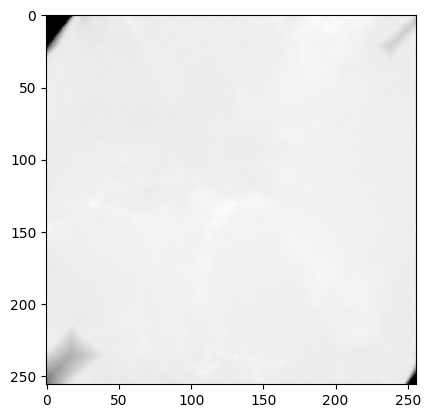

Label: 4


In [29]:
train, labels = next(iter(data_loader))
print(f"Feature batch shape: {train.size()}")
print(f"Feature batch type: {train.type()}")
print(f"Labels batch shape: {labels.size()}")
img = train[31].squeeze()
label = labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

In [10]:
model.load_state_dict(torch.load("mymodel_classified.pth"))
model.to(device)
outputs = model(train.to(device))

In [11]:
labels

tensor([4, 3, 0, 0, 3, 3, 1, 2, 0, 0, 3, 2, 3, 3, 0, 0, 3, 1, 3, 0, 4, 4, 3, 4,
        0, 0, 0, 0, 0, 0, 4, 0, 4, 3, 1, 2, 1, 2, 0, 0, 4, 4, 2, 0, 1, 2, 3, 3,
        1, 0, 1, 1, 1, 3, 4, 2, 2, 4, 0, 0, 3, 1, 3, 1])

In [13]:
outputs

tensor([[-6.3982e-01, -4.2503e-01, -3.1748e+00,  4.2739e-01,  5.8007e+00],
        [-3.4907e+00, -2.2399e+00,  1.1482e+00,  2.8751e+00,  7.4749e-01],
        [ 1.9387e+00,  1.6566e+00,  1.5916e+00,  1.1602e+00, -5.5209e+00],
        [ 3.3682e+00,  3.7220e+00,  2.8525e+00, -1.6954e+00, -3.6887e+00],
        [ 2.2381e+00, -2.1552e+00,  1.0470e+00,  1.0893e+00, -9.7186e-01],
        [ 7.4472e-01,  8.2110e-01,  6.4554e-01,  4.1414e-01, -2.3670e+00],
        [ 5.3762e-01,  3.9302e+00, -6.9859e-02,  4.6734e-01, -3.0236e+00],
        [-1.2388e+01,  3.5849e-01,  1.8160e+01,  5.0803e+00,  5.1369e+00],
        [ 5.6883e+00,  2.4076e-01,  1.5716e-02, -3.2993e+00, -3.5005e-01],
        [ 2.8498e+00,  3.0924e+00,  1.0186e+00, -1.4498e-01, -3.6787e+00],
        [-4.8309e+00,  5.3082e+00, -1.4836e+00,  8.8498e+00, -3.4031e+00],
        [ 2.3284e+00,  2.5516e+00,  1.8726e+00, -3.9887e+00,  2.0111e+00],
        [-2.1396e+00, -3.1301e-01, -1.0773e+00,  4.9505e+00,  6.9735e-01],
        [-3.7376e+00,  9.

In [12]:
_, predicted = torch.max(outputs,1)
total = len(labels)
correct = 0

for label, prediction in zip(labels, predicted.detach().cpu()):
    if label == prediction:
        #print(label, prediction)
        correct = correct + 1

print(f'Accuracy: {(correct/total):5f}')

Accuracy: 0.718750


In [14]:
predicted

tensor([4, 3, 0, 1, 0, 1, 1, 2, 0, 1, 3, 1, 3, 3, 0, 0, 3, 1, 3, 0, 4, 1, 2, 1,
        1, 0, 1, 4, 0, 3, 4, 0, 4, 3, 1, 0, 1, 2, 0, 0, 3, 4, 2, 0, 0, 2, 3, 3,
        1, 0, 1, 1, 1, 3, 4, 2, 0, 4, 1, 0, 3, 2, 3, 1], device='cuda:0')